# Problem B — Binary Classification: Normal vs IBM
**Local execution version** — based on Burlina et al. (2017) group definitions.

Set `BASE_DIR` in Configuration to your local data folder.

In [8]:
import os, json, cv2, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
warnings.filterwarnings('ignore')
print("TF version:", tf.__version__)


TF version: 2.20.0


## Configuration

In [9]:
# ── Paths ──────────────────────────────────────────────────
BASE_DIR    = r'.'                                 # <-- CHANGE IF NEEDED
EXCEL_PATH  = os.path.join(BASE_DIR, 'PatientImages_MATCHED.xlsx')
IMAGE_DIR   = os.path.join(BASE_DIR, 'processed_images')
RESULTS_DIR = os.path.join(BASE_DIR, 'results_B')
os.makedirs(RESULTS_DIR, exist_ok=True)

# ── Hyper-params ────────────────────────────────────────────
IMG_SIZE      = 224
BATCH_SIZE    = 32
LEARNING_RATE = 1e-5
EPOCHS        = 50
UNFREEZE_LAYERS = 80
SEED          = 42

MODELS_TO_RUN = ["ResNet50", "ResNet101", "EfficientNetB0",
                 "EfficientNetB4", "DenseNet121", "InceptionV3", "Xception"]

## Load & Label Data
**Classes:** N=0 (Normal), I=1 (IBM)

In [10]:
df = pd.read_excel(EXCEL_PATH)
diag_col  = [c for c in df.columns if "diagn" in c.lower()][0]
image_col = [c for c in df.columns if c.strip().lower() == 'filename'] or \
            [c for c in df.columns if "image" in c.lower() or "file" in c.lower()]
image_col = image_col[0]

# Problem B: Normal (N) vs IBM (I)
df_b = df[df[diag_col].isin(['N', 'I'])].copy()
df_b['label'] = df_b[diag_col].map({'N': 0, 'I': 1})
df_b['path']  = df_b[image_col].apply(lambda f: os.path.join(IMAGE_DIR, str(f)))
df_b = df_b[df_b['path'].apply(os.path.exists)].reset_index(drop=True)
print(f"Valid images: {len(df_b)}")
print(df_b['label'].value_counts().rename({0:'Normal', 1:'IBM'}))

Valid images: 452
label
Normal    246
IBM       206
Name: count, dtype: int64


## Train / Val / Test Split

In [11]:
train_df, temp_df = train_test_split(df_b, test_size=0.3, stratify=df_b['label'], random_state=SEED)
val_df,   test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['label'], random_state=SEED)
print(f"Train: {len(train_df)}  Val: {len(val_df)}  Test: {len(test_df)}")
CLASS_NAMES = ['Normal', 'IBM']

Train: 316  Val: 68  Test: 68


## Build Datasets, Augmentation & Class Weights

In [12]:
augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.05),
    layers.RandomTranslation(0.04, 0.04),
], name="augmentation")

def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def make_dataset(dataframe, augment=False, shuffle=False):
    paths  = dataframe['path'].values
    labels = dataframe['label'].values.astype('float32')
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle: ds = ds.shuffle(1024)
    if augment:
        ds = ds.map(lambda x, y: (augmentation(x, training=True), y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

cw = compute_class_weight('balanced', classes=np.unique(train_df['label']), y=train_df['label'])
class_weight = dict(enumerate(cw))
print("Class weights:", class_weight)

train_ds = make_dataset(train_df, augment=True,  shuffle=True)
val_ds   = make_dataset(val_df,  augment=False, shuffle=False)
test_ds  = make_dataset(test_df, augment=False, shuffle=False)
print("Datasets ready.")

Class weights: {0: np.float64(0.9186046511627907), 1: np.float64(1.0972222222222223)}
Datasets ready.


## Model Definitions

In [13]:
def get_base(name):
    kw = dict(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))
    return {
        'ResNet50':       keras.applications.ResNet50(**kw),
        'ResNet101':      keras.applications.ResNet101(**kw),
        'EfficientNetB0': keras.applications.EfficientNetB0(**kw),
        'EfficientNetB4': keras.applications.EfficientNetB4(**kw),
        'DenseNet121':    keras.applications.DenseNet121(**kw),
        'InceptionV3':    keras.applications.InceptionV3(**kw),
        'Xception':       keras.applications.Xception(**kw),
    }[name]

def build_binary_model(model_name):
    base = get_base(model_name)
    for layer in base.layers:
        layer.trainable = False
    for layer in base.layers[-UNFREEZE_LAYERS:]:
        if not isinstance(layer, layers.BatchNormalization):
            layer.trainable = True

    inputs  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x       = base(inputs, training=False)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(512, activation='relu')(x)
    x       = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    model   = keras.Model(inputs, outputs, name=model_name)
    model.compile(
        optimizer=keras.optimizers.Adam(LEARNING_RATE),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc')]
    )
    return model

## Train All Models & Evaluate


  Training: ResNet50
171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 302s 2us/step
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 34s 2us/step
71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 60s 1us/step
29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 15s 1us/step
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 36s 0us/step
83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 195s 2us/step
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 34s 2s/step - accuracy: 0.4810 - auc: 0.4771 - loss: 0.7448 - val_accuracy: 0.4559 - val_auc: 0.5323 - val_loss: 0.7257 - learning_rate: 1.0000e-05
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.5095 - auc: 0.5155 - loss: 0.7061 - val_accuracy: 0.4559 - val_auc: 0.7594 - val_loss: 0.6933 - learning_rate: 1.0000e-05
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 24s 2s/step - accuracy: 0.5158 - auc: 0.5131 - loss: 0.6980 - val_accuracy: 0.4559 - val_auc: 0.8091 - val_loss: 0.6944 - learning_rate: 1.0000e-05
Epoch 4/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 22s 2s/step - accuracy: 0.5380 - auc: 0.5188 - loss: 0.6960 - val_

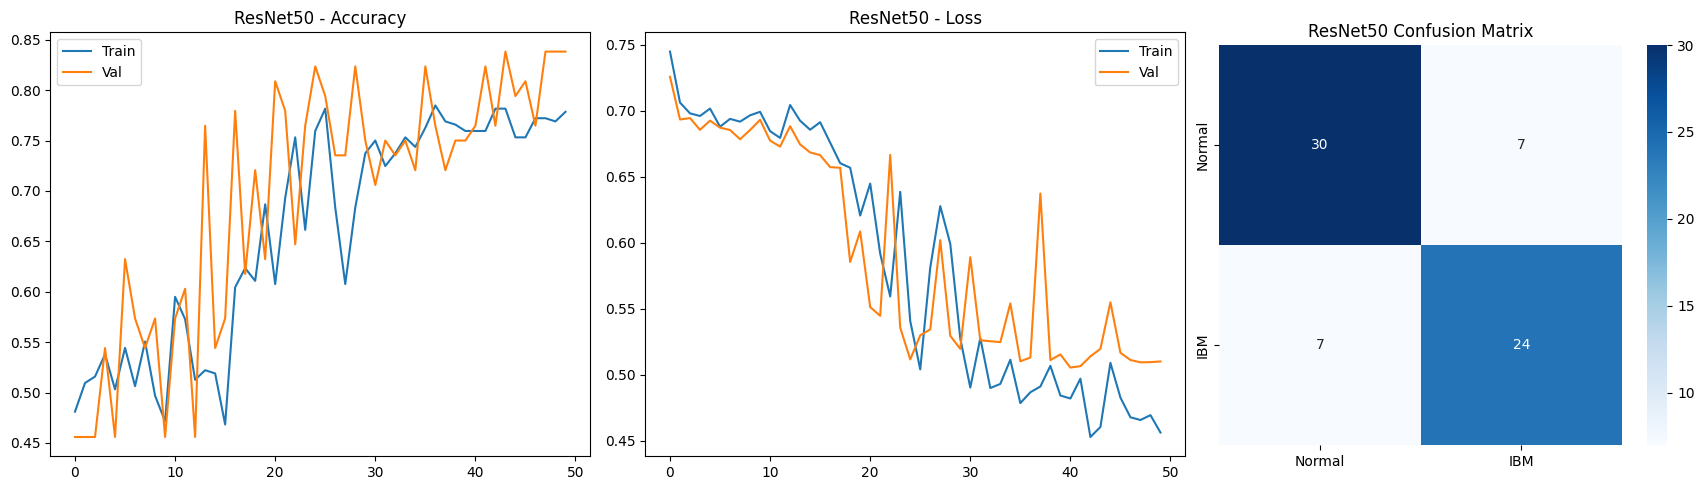

              precision    recall  f1-score   support

      Normal       0.81      0.81      0.81        37
         IBM       0.77      0.77      0.77        31

    accuracy                           0.79        68
   macro avg       0.79      0.79      0.79        68
weighted avg       0.79      0.79      0.79        68

{
  "model": "ResNet50",
  "test_acc": 0.7941,
  "test_auc": 0.8801,
  "f1_macro": 0.7925,
  "best_val_acc": 0.8382,
  "best_val_auc": 0.8566,
  "epochs": 50
}

  Training: ResNet101
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 65s 5s/step - accuracy: 0.4810 - auc: 0.4912 - loss: 0.7434 - val_accuracy: 0.4559 - val_auc: 0.6299 - val_loss: 0.6932 - learning_rate: 1.0000e-05
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 45s 4s/step - accuracy: 0.4873 - auc: 0.5067 - loss: 0.7003 - val_accuracy: 0.7647 - val_auc: 0.8095 - val_loss: 0.6895 - learning_rate: 1.0000e-05
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 42s 4s/step - accuracy: 0.4905 - auc: 0.4932 - loss: 0.7057 - val_accuracy: 0.77

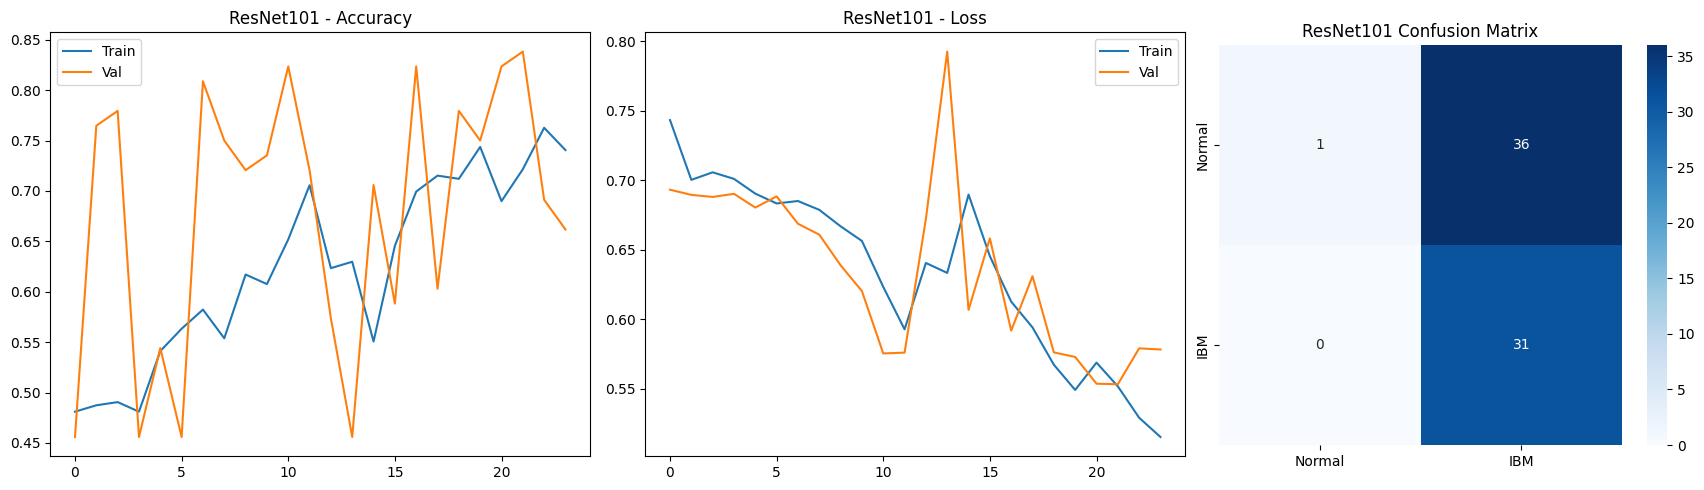

              precision    recall  f1-score   support

      Normal       1.00      0.03      0.05        37
         IBM       0.46      1.00      0.63        31

    accuracy                           0.47        68
   macro avg       0.73      0.51      0.34        68
weighted avg       0.76      0.47      0.32        68

{
  "model": "ResNet101",
  "test_acc": 0.4706,
  "test_auc": 0.8836,
  "f1_macro": 0.3426,
  "best_val_acc": 0.8382,
  "best_val_auc": 0.857,
  "epochs": 24
}

  Training: EfficientNetB0
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.5253 - auc: 0.5010 - loss: 0.6978 - val_accuracy: 0.4559 - val_auc: 0.5000 - val_loss: 0.6934 - learning_rate: 1.0000e-05
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 887ms/step - accuracy: 0.4810 - auc: 0.4925 - loss: 0.6963 - val_accuracy: 0.5441 - val_auc: 0.5000 - val_loss: 0.6906 - learning_rate: 1.0000e-05
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 871ms/step - accuracy: 0.4778 - auc: 0.4830 - loss: 0.6965 - val_acc

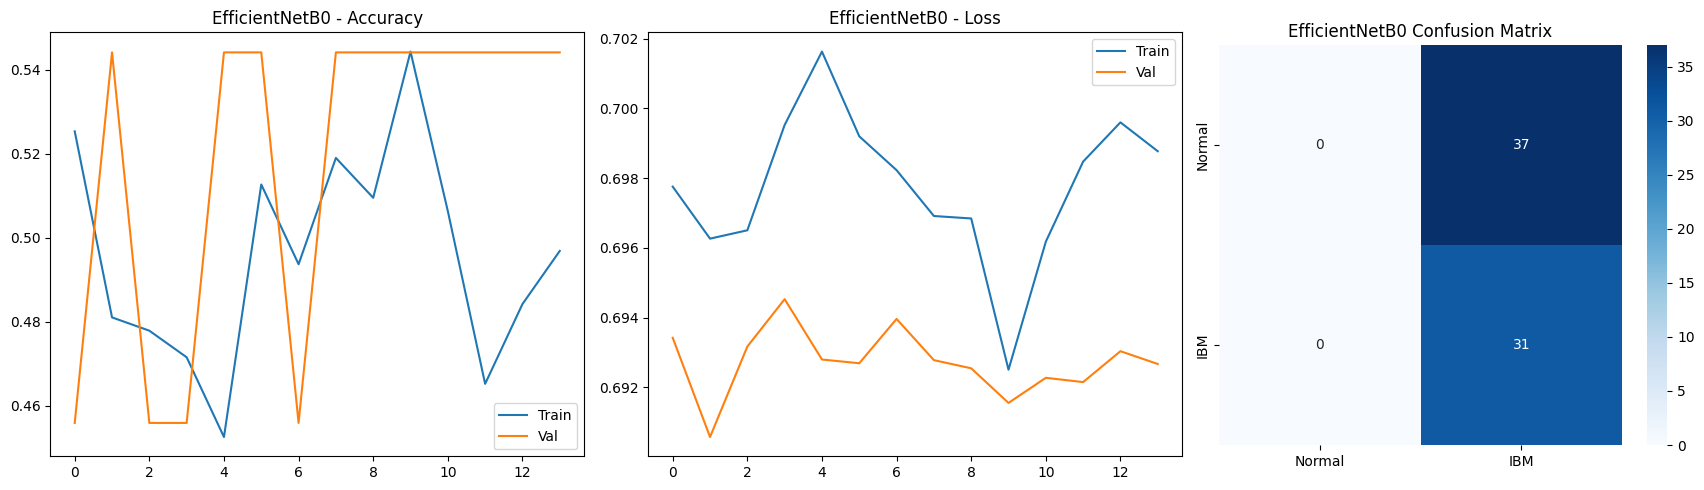

              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00        37
         IBM       0.46      1.00      0.63        31

    accuracy                           0.46        68
   macro avg       0.23      0.50      0.31        68
weighted avg       0.21      0.46      0.29        68

{
  "model": "EfficientNetB0",
  "test_acc": 0.4559,
  "test_auc": 0.6129,
  "f1_macro": 0.3131,
  "best_val_acc": 0.5441,
  "best_val_auc": 0.6155,
  "epochs": 14
}

  Training: EfficientNetB4
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 52s 3s/step - accuracy: 0.5253 - auc: 0.5161 - loss: 0.6978 - val_accuracy: 0.4853 - val_auc: 0.6046 - val_loss: 0.6926 - learning_rate: 1.0000e-05
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 23s 2s/step - accuracy: 0.5127 - auc: 0.5259 - loss: 0.6927 - val_accuracy: 0.4559 - val_auc: 0.5135 - val_loss: 0.6966 - learning_rate: 1.0000e-05
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.4589 - auc: 0.4425 - loss: 0.7020 - val_acc

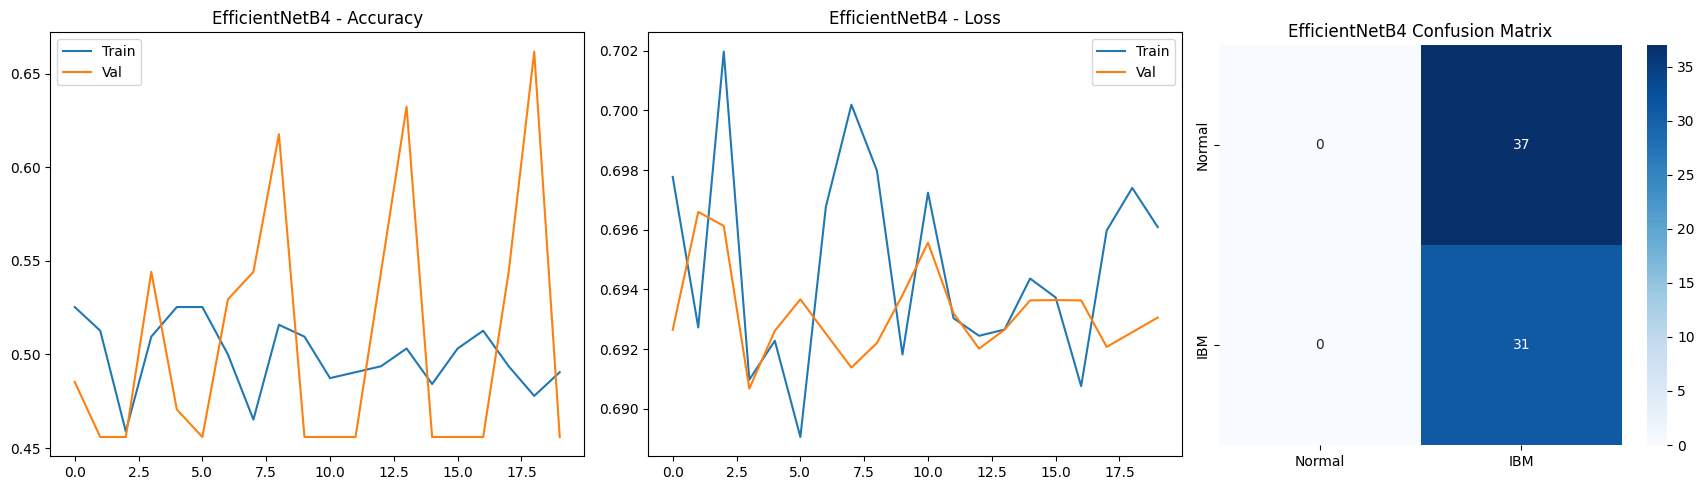

              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00        37
         IBM       0.46      1.00      0.63        31

    accuracy                           0.46        68
   macro avg       0.23      0.50      0.31        68
weighted avg       0.21      0.46      0.29        68

{
  "model": "EfficientNetB4",
  "test_acc": 0.4559,
  "test_auc": 0.6068,
  "f1_macro": 0.3131,
  "best_val_acc": 0.6618,
  "best_val_auc": 0.6874,
  "epochs": 20
}

  Training: DenseNet121
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 36s 2s/step - accuracy: 0.5570 - auc: 0.5427 - loss: 0.7180 - val_accuracy: 0.4706 - val_auc: 0.5170 - val_loss: 0.7121 - learning_rate: 1.0000e-05
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.5538 - auc: 0.5812 - loss: 0.6970 - val_accuracy: 0.5735 - val_auc: 0.6216 - val_loss: 0.6781 - learning_rate: 1.0000e-05
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step - accuracy: 0.6044 - auc: 0.6340 - loss: 0.6644 - val_accura

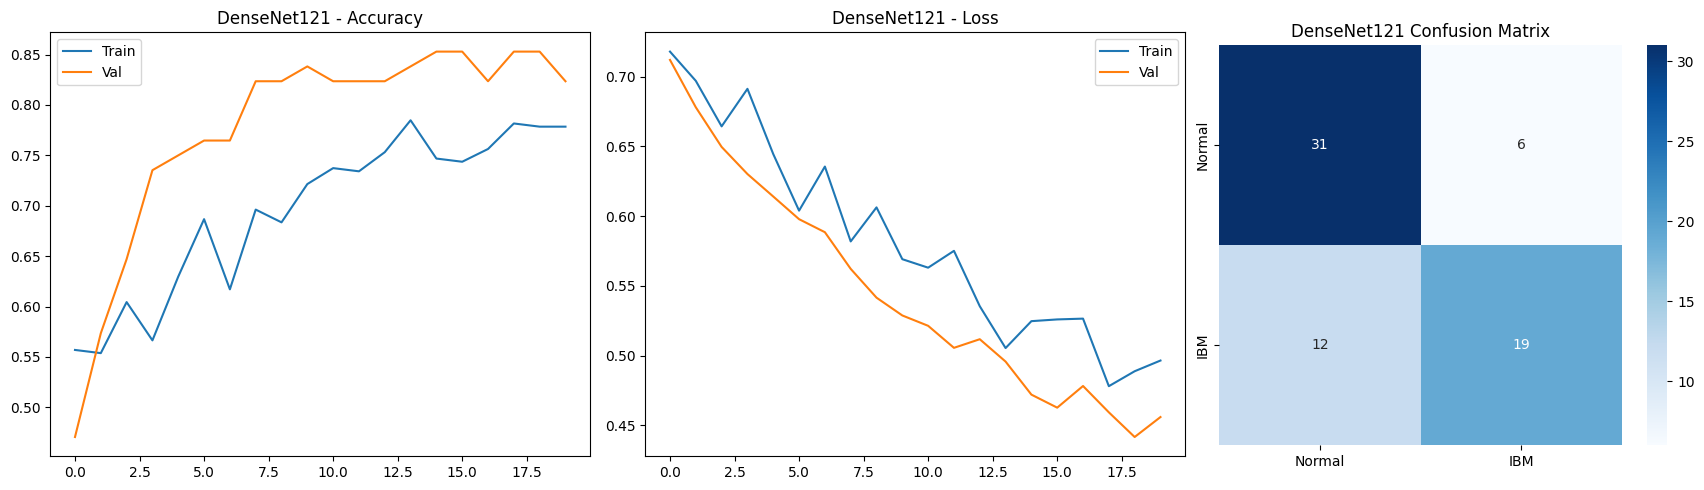

              precision    recall  f1-score   support

      Normal       0.72      0.84      0.78        37
         IBM       0.76      0.61      0.68        31

    accuracy                           0.74        68
   macro avg       0.74      0.73      0.73        68
weighted avg       0.74      0.74      0.73        68

{
  "model": "DenseNet121",
  "test_acc": 0.7353,
  "test_auc": 0.8457,
  "f1_macro": 0.7268,
  "best_val_acc": 0.8529,
  "best_val_auc": 0.9159,
  "epochs": 20
}

  Training: InceptionV3
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 25s 2s/step - accuracy: 0.5506 - auc: 0.5398 - loss: 0.7490 - val_accuracy: 0.6176 - val_auc: 0.7167 - val_loss: 0.6497 - learning_rate: 1.0000e-05
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 19s 2s/step - accuracy: 0.6424 - auc: 0.7020 - loss: 0.6305 - val_accuracy: 0.7059 - val_auc: 0.8221 - val_loss: 0.6160 - learning_rate: 1.0000e-05
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 17s 2s/step - accuracy: 0.6867 - auc: 0.7614 - loss: 0.5872 - val_accuracy:

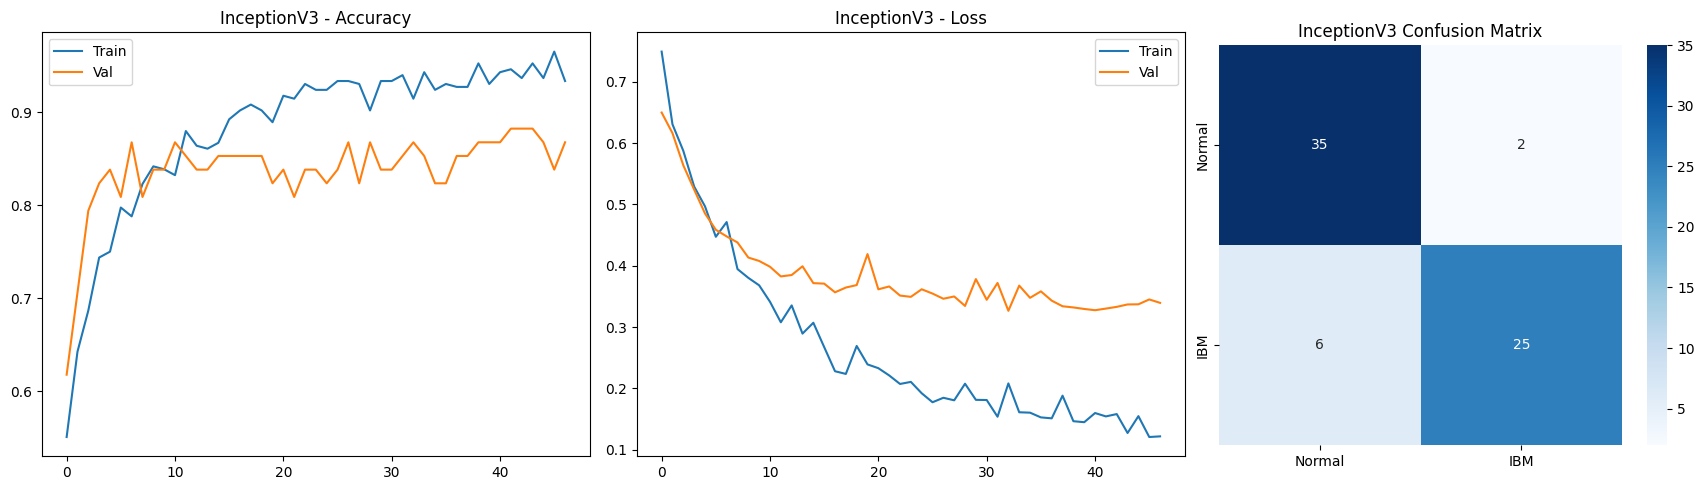

              precision    recall  f1-score   support

      Normal       0.85      0.95      0.90        37
         IBM       0.93      0.81      0.86        31

    accuracy                           0.88        68
   macro avg       0.89      0.88      0.88        68
weighted avg       0.89      0.88      0.88        68

{
  "model": "InceptionV3",
  "test_acc": 0.8824,
  "test_auc": 0.9215,
  "f1_macro": 0.8798,
  "best_val_acc": 0.8824,
  "best_val_auc": 0.9377,
  "epochs": 47
}

  Training: Xception
Epoch 1/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 43s 4s/step - accuracy: 0.5285 - auc: 0.5111 - loss: 0.7114 - val_accuracy: 0.5441 - val_auc: 0.5972 - val_loss: 0.6824 - learning_rate: 1.0000e-05
Epoch 2/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.6392 - auc: 0.7014 - loss: 0.6588 - val_accuracy: 0.6029 - val_auc: 0.7502 - val_loss: 0.6608 - learning_rate: 1.0000e-05
Epoch 3/50
10/10 ━━━━━━━━━━━━━━━━━━━━ 35s 3s/step - accuracy: 0.6772 - auc: 0.7420 - loss: 0.6387 - val_accuracy: 0.

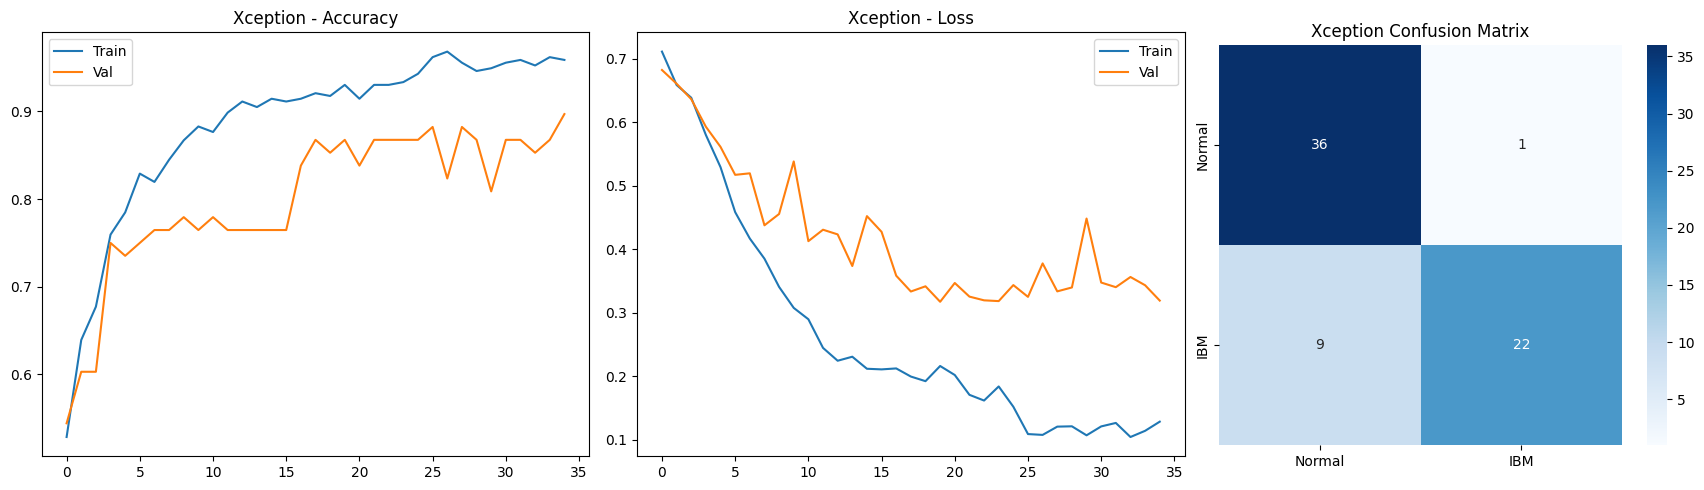

              precision    recall  f1-score   support

      Normal       0.80      0.97      0.88        37
         IBM       0.96      0.71      0.81        31

    accuracy                           0.85        68
   macro avg       0.88      0.84      0.85        68
weighted avg       0.87      0.85      0.85        68

{
  "model": "Xception",
  "test_acc": 0.8529,
  "test_auc": 0.9512,
  "f1_macro": 0.8464,
  "best_val_acc": 0.8971,
  "best_val_auc": 0.9477,
  "epochs": 35
}

All models done!


In [14]:
all_results = []

for model_name in MODELS_TO_RUN:
    print(f"\n{'='*60}")
    print(f"  Training: {model_name}")
    print(f"{'='*60}")

    keras.backend.clear_session()
    model = build_binary_model(model_name)

    ckpt_path = os.path.join(RESULTS_DIR, f'{model_name}_best.keras')
    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_auc', patience=10,
                                       restore_best_weights=True, mode='max'),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=5,
                                           factor=0.5, min_lr=1e-7),
        keras.callbacks.ModelCheckpoint(ckpt_path, monitor='val_auc',
                                         save_best_only=True, mode='max'),
        keras.callbacks.CSVLogger(os.path.join(RESULTS_DIR, f'{model_name}_log.csv')),
    ]

    history = model.fit(
        train_ds, validation_data=val_ds, epochs=EPOCHS,
        class_weight=class_weight, callbacks=callbacks, verbose=1
    )

    # ── Evaluate
    test_metrics = model.evaluate(test_ds, verbose=0)
    y_true = np.concatenate([y.numpy() for _, y in test_ds])
    y_prob  = model.predict(test_ds, verbose=0).ravel()
    y_pred  = (y_prob >= 0.5).astype(int)
    f1 = f1_score(y_true, y_pred, average='macro')

    # ── Plot
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, key, title in zip(axes, ['accuracy','loss','auc'],
                                      ['Accuracy','Loss','AUC']):
        ax.plot(history.history[key],      label='Train')
        ax.plot(history.history[f'val_{key}'], label='Val')
        ax.set_title(f'{model_name} - {title}'); ax.legend()
    cm = confusion_matrix(y_true, y_pred)
    axes[2].set_visible(False)
    fig.add_axes([0.68, 0.1, 0.28, 0.8])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
    plt.title(f'{model_name} Confusion Matrix')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, f'{model_name}_results.png'), dpi=120)
    plt.show()

    result = {
        'model': model_name,
        'test_acc': round(test_metrics[1], 4),
        'test_auc': round(test_metrics[2], 4),
        'f1_macro': round(f1, 4),
        'best_val_acc': round(max(history.history['val_accuracy']), 4),
        'best_val_auc': round(max(history.history['val_auc']), 4),
        'epochs': len(history.history['accuracy']),
    }
    all_results.append(result)
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
    print(json.dumps(result, indent=2))

print("\nAll models done!")

## Model Comparison Table

         model  test_acc  test_auc  f1_macro  best_val_acc  best_val_auc  epochs
   InceptionV3    0.8824    0.9215    0.8798        0.8824        0.9377      47
      Xception    0.8529    0.9512    0.8464        0.8971        0.9477      35
      ResNet50    0.7941    0.8801    0.7925        0.8382        0.8566      50
   DenseNet121    0.7353    0.8457    0.7268        0.8529        0.9159      20
     ResNet101    0.4706    0.8836    0.3426        0.8382        0.8570      24
EfficientNetB0    0.4559    0.6129    0.3131        0.5441        0.6155      14
EfficientNetB4    0.4559    0.6068    0.3131        0.6618        0.6874      20


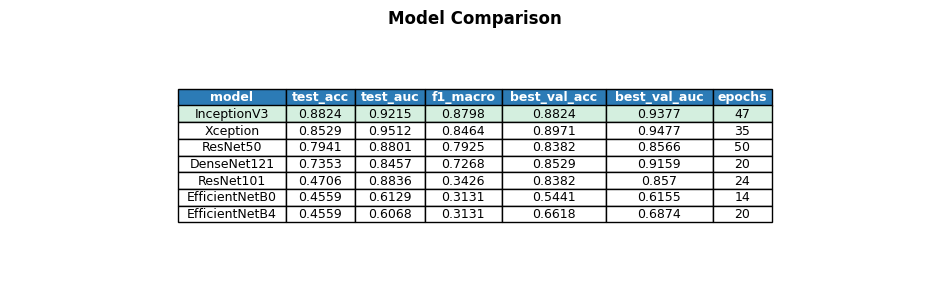

Comparison table saved.


In [15]:
df_res = pd.DataFrame(all_results).sort_values('test_acc', ascending=False)
df_res.to_csv(os.path.join(RESULTS_DIR, 'comparison.csv'), index=False)
print(df_res.to_string(index=False))

# Plot comparison table
fig, ax = plt.subplots(figsize=(12, 3))
ax.axis('off')
tbl = ax.table(cellText=df_res.values, colLabels=df_res.columns,
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
tbl.auto_set_column_width(col=list(range(len(df_res.columns))))
for j in range(len(df_res.columns)):
    tbl[0, j].set_facecolor('#2c7bb6')
    tbl[0, j].set_text_props(color='white', fontweight='bold')
    tbl[1, j].set_facecolor('#d4efdf')
plt.title('Model Comparison', fontweight='bold', pad=12)
plt.savefig(os.path.join(RESULTS_DIR, 'comparison_table.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Comparison table saved.")